# Cloning quasars

In [1]:
import numpy as np
from scipy.stats import norm
from matplotlib import pyplot as plt
import astropy

In [2]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

data

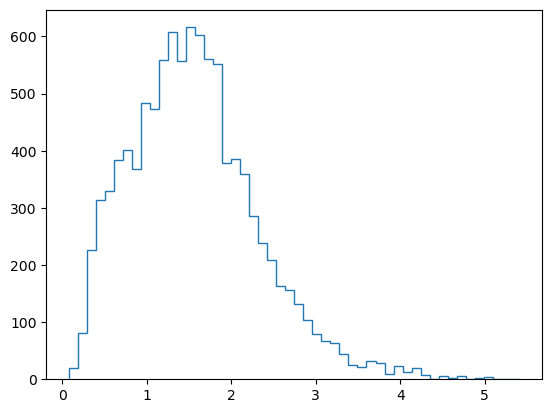

In [3]:
counts, bins = np.histogram(z, bins=50)
plt.stairs(counts, bins)
xmax=np.max(bins)
ymax=np.max(counts)

upsample with rejection sampling

In [4]:
	
new=[]
while len(new) < 10000:
    x = np.random.uniform(0,xmax)
    for i in range (0,51):
        if (bins[i]<x<bins[i+1]):
            y = np.random.uniform(0,ymax)
            if(y<counts[i]):
                new.append(x)

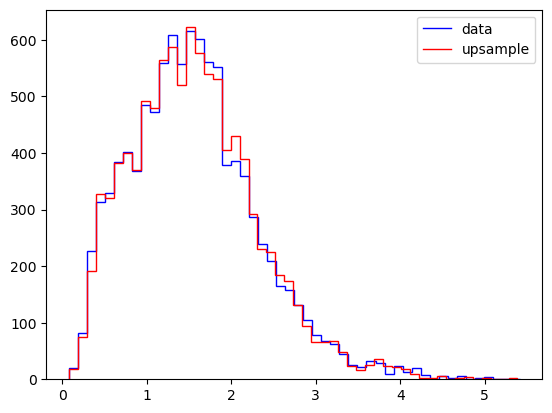

In [5]:
counts_new, bins_new = np.histogram(new, bins=50)
plt.stairs(counts, bins, color='blue', label='data')
plt.stairs(counts_new, bins_new, color='red', label='upsample')
plt.legend()

upsample with inverse transform sampling

In [6]:
cdf=np.cumsum(counts/10000)
cdf

array([0.002 , 0.0101, 0.0327, 0.064 , 0.097 , 0.1354, 0.1755, 0.2123,
       0.2607, 0.308 , 0.3638, 0.4246, 0.4803, 0.5419, 0.6021, 0.6582,
       0.7133, 0.7512, 0.7897, 0.8256, 0.8542, 0.8781, 0.899 , 0.9154,
       0.9311, 0.9442, 0.9546, 0.9625, 0.9692, 0.9755, 0.98  , 0.9825,
       0.9847, 0.9879, 0.9907, 0.9916, 0.9939, 0.9951, 0.9971, 0.9979,
       0.998 , 0.9985, 0.9987, 0.9992, 0.9993, 0.9995, 0.9999, 0.9999,
       0.9999, 1.    ])

In [7]:
new=[]

while len(new) < 10000:
    y = np.random.uniform(0,1)
    if y<cdf[0]:
        new.append(bins[0])
    for i in range (0,50):
        if (cdf[i]<y<cdf[i+1]):
            new.append(bins[i+1])

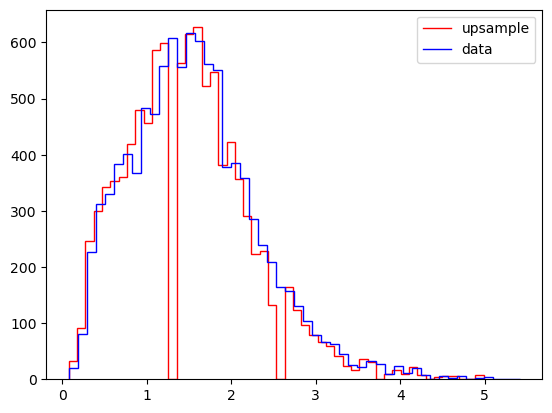

In [8]:
b_new, a_new = np.histogram(new, bins=50)
plt.stairs(b_new, a_new, color='red', label='upsample')
plt.stairs(counts, bins, color='blue', label='data')
plt.legend()

In [9]:
astropy.cosmology.Planck18

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897)

In [10]:
z_vals = np.linspace(0,5,100)
comvol = astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value

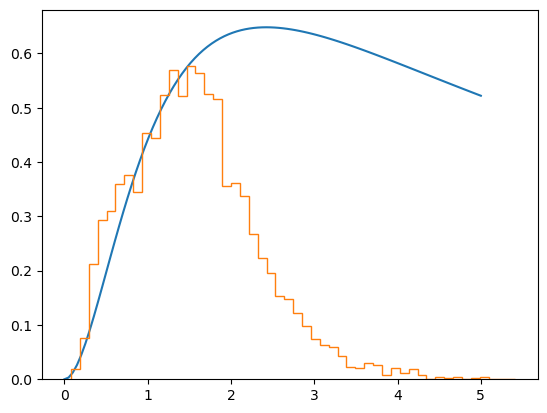

In [11]:
redshift = np.linspace(0,5,100)
plt.plot(redshift,comvol/6.5e10) ###   Arbitrary normalization, just matching by eye

plt.hist(z,bins=50,histtype='step',density=True,label='original data');